# Summary

This notebook shows how to use the probabilistic model to generate data from an underlying _Multiscale Non-stationary Directed Acyclic Graph_ (MN-DAG).

The user can specify:
- the number of time series $N$ and their length $T$,
- prior concerning the number of pages in the MN-DAG, by setting the value for $\mu \in \mathbb{R}$. Indeed, we have that the number of macìximum scale levels $J \sim 1+\text{Binomial}(\mu, \log_2(T))-1$, with $\mu$ being the probability of success and $\log_2(T)-1$ the number of trials. Note that we assume we have at least one time scale, that is, the finest one corresponding to the $j=1$ level;
- the temporal dependence of the causal coefficients, through the type of kernel $K$ used in the batched Gaussian Process ($GP$). As an example, here we will use $K=K_{\text{linear}}K_{\text{Matern3/2}}+K_{\text{Periodic}}$;
- prior related to the density of the causal structure, by providing the value for $\delta\in \mathbb{R}$. To this end, we multiply element-wise the tensor of causal coefficients by a logical tensor $\Pi \in [0,1]^{J \times T \times N \times N} \mid \pi_{j:nm}\sim \text{Bernoulli}(\delta)$.

Finally, the causal relationships for each time resolution and some statistics regarding the generated time series are displayed.

# Libraries

In [1]:
import torch
import statsmodels.api as sms
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from pyro.contrib.gp.kernels import Linear, Matern32, Periodic, Product, Sum
from statsmodels.tsa.stattools import adfuller

from generators.probabilistic_generator import Generator

In [2]:
#detect the presence of gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [3]:
#params for the plots
sns.set_context('talk')
plt.rcParams['text.usetex'] = True

# Generate synthetic data

In [4]:
N=3 #number of time series
T=2**9 #length of time series 
density=.5 #parameter of Bernoulli dist
multiscale=.5 #probability of success of Binomial dist
nonstationarity=.5 #lengthscale of kernels

one = torch.ones(1)
zero = torch.zeros(1)

kern0 = Linear(1, one) #Linear kernel
kern1= Matern32(1, one, 1/nonstationarity*one) #Matern kernel
kern2= Periodic(1, one, 1/nonstationarity*one, 1/nonstationarity*one) #Periodic kernel

Kernel = Sum(Product(kern0, kern1), kern2) #locally periodic with increasing variation (see https://www.cs.toronto.edu/~duvenaud/cookbook/)

In [5]:
gen = Generator(N=N, T=T, multiscale=multiscale, nonstationarity=nonstationarity, density=density, kernel=Kernel) #instantiate the generator
X=gen.generate() #generate the time series

In [6]:
#you can inspect all the relevant quantities 
#involved in the data generation process.
#Please, have a look at "generators/probabilistic_generator.py".
print(r'Causal ordering={}; Total number of time scales J={}.'.format(gen.ordering.numpy(), gen.J.item()))

Causal ordering=[0 2 1]; Total number of time scales J=5.


In [7]:
#store data in a pandas dataframe for convinience
data=pd.DataFrame(X.numpy(), columns=["1","2","3"])
data

,1,2,3
0,-0.831223,3.049929,3.903151
1,-0.386988,7.703068,-1.027265
2,2.721828,5.909978,0.277181
3,3.269531,3.186648,0.594293
4,5.041724,3.001644,3.692693
...,...,...,...
507,0.199171,-5.637687,-4.021120
508,-2.141183,5.530250,6.999749
509,-2.087290,-9.939395,-7.997637
510,1.360906,-19.829197,-0.491125


# Plot MN-DAG

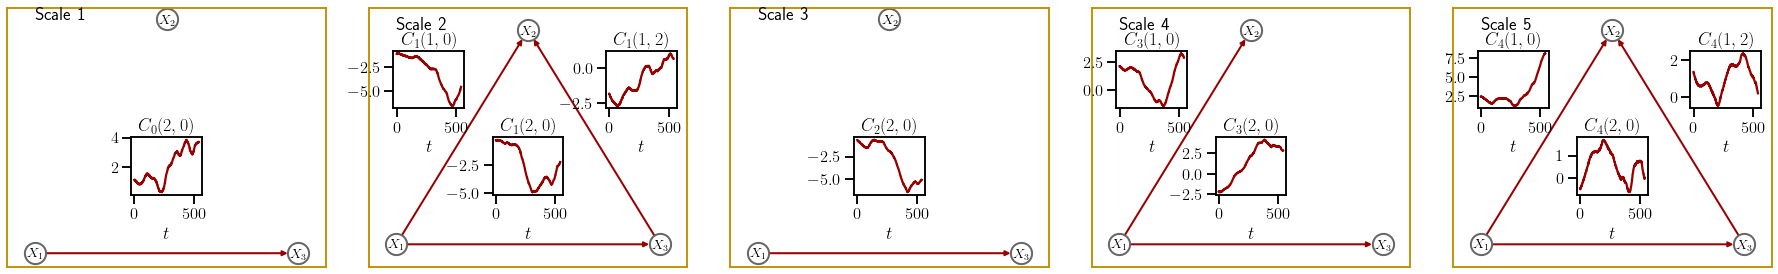

In [8]:
#example of code for plotting
#causal interactions at each scale.
#If you did not set N=3 above,
#then change the code below accordingly
#in order to get proper plots.

#position of subfigs concerning the evolution
#of causal relations over time
subfig_dict = {(0,1):[0.17, 0.65, .2, .2],(0,2):[0.45, 0.35, .2, .2],(1,2):[0.77, 0.65, .2, .2]} 

#main figure
fig = plt.figure(constrained_layout=True, figsize=(5*int(gen.J),4))

#subfigs for graph pages, plotted on a single row
subfigs = fig.subfigures(1, gen.J.item())

#loop over time resolutions
for j, subfig in enumerate(subfigs.flat):
    ax1=subfig.add_axes([0.1, 0.1, .9, .9])
    plt.setp(ax1.spines.values(), color='#BF9000')
    plt.setp([ax1.get_xticklines(), ax1.get_yticklines()], color='#BF9000')
    
    #plot network with networkx
    G=nx.from_numpy_matrix(gen.C[j,0].numpy().T, create_using=nx.DiGraph)
    nx.draw_networkx(G, pos={0:(0,0), 1:(.5,1), 2:(1,0)}, with_labels=False, node_color='white', edgecolors='#666666', edge_color='#980000', width=2, node_size=450, linewidths=2, ax=ax1)
    ax1.text(0,1.,s="Scale {}".format(j+1))
    ax1.text(-.03,-.02,s="$X_{1}$", fontsize=14, fontweight='bold')
    ax1.text(.97,-.02,s="$X_{3}$", fontsize=14, fontweight='bold')
    ax1.text(.47,.98,s="$X_{2}$", fontsize=14, fontweight='bold')

    #obtain the indices of nonzero causal relations
    idxs = torch.nonzero(gen.C[j,0,...], as_tuple=False)

    #plot the evolution over time of causal relations
    axs = []
    for row in range(idxs.shape[0]):
        key = tuple(idxs[row].sort()[0].numpy())
        nodes = tuple(idxs[row].numpy())
        axs.append(subfig.add_axes(subfig_dict[key]))
        axs[row].set_xlabel("$t$")
        axs[row].set_title(r"$C_{}{}$".format(j,nodes))
        sns.lineplot(data=gen.C[j,:,nodes[0], nodes[1]], color='#980000', ax=axs[row])
    
plt.show()

# Statistics of data

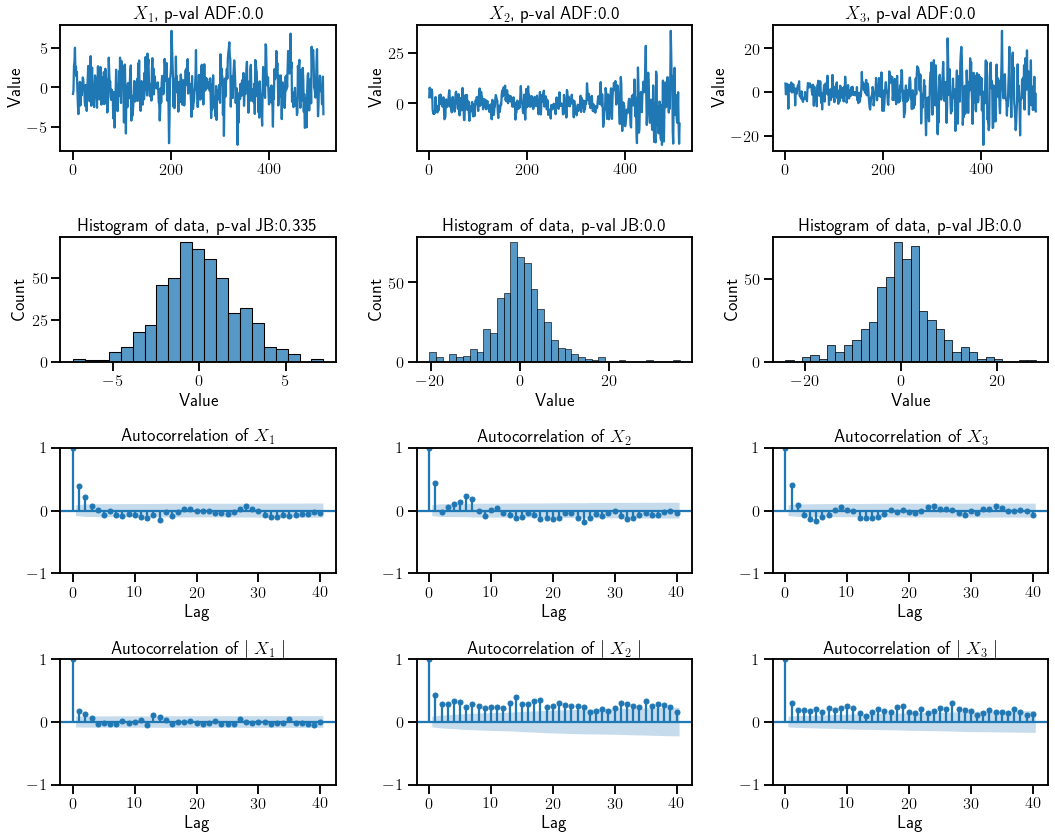

In [10]:
fig, ax = plt.subplots(4,N, figsize=(15,12))

#loop over nodes
for n in range(N): 
    #Time series over time, Augmented Dickey-Fuller test (H0: the process is non-stationarity), Jarque-Bera test
    sns.lineplot(data=data.iloc[:,n], ax=ax[0,n])
    ax[0,n].set_ylabel(r'Value')
    ax[0,n].set_title(r'$X_{}$, p-val ADF:{}'.format(n+1, round(adfuller(data.iloc[:,n])[1],3)))
    
    #Data histogram, Jarque-Bera test (H0: data are normally distributed)
    sns.histplot(data.iloc[:,n], ax=ax[1,n])
    ax[1,n].set_title(r'Histogram of data, p-val JB:{}'.format(round(sms.stats.jarque_bera(data.iloc[:,n])[1],3)))
    ax[1,n].set_xlabel(r'Value')

    #Autocorrelation
    sms.graphics.tsa.plot_acf(data.iloc[:,n], lags=40, ax=ax[2,n])
    ax[2,n].set_title(r"Autocorrelation of $X_{}$".format(n+1))
    ax[2,n].set_xlabel(r'Lag')
    
    #Autocorrelation of absolute values to detect volatility clustering
    sms.graphics.tsa.plot_acf(data.iloc[:,n].abs(), lags=40, ax=ax[3,n])
    ax[3,n].set_title(r"Autocorrelation of $\mid X_{} \mid$".format(n+1))
    ax[3,n].set_xlabel(r'Lag')

plt.tight_layout()
plt.show()